In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [113]:
df = pd.read_csv("data.csv")

X = df[['Ia', 'Ib', 'VDC', 'IDC', 'T1', 'T2', 'T3', 'VD']]
y = df['FDD']

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [115]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [116]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")

Accuracy: 99.17393299678751%


In [117]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9965568690462527
Test Accuracy: 0.9917393299678752


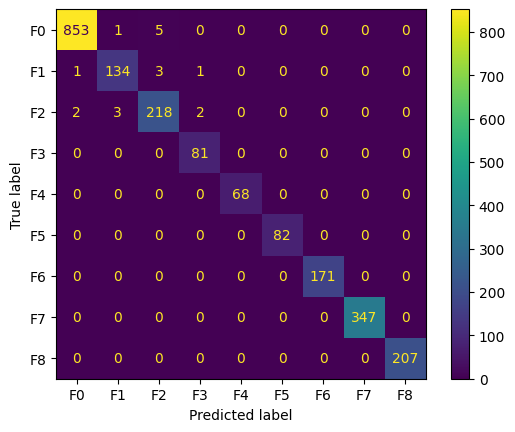

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          F0       1.00      0.99      0.99       859
          F1       0.97      0.96      0.97       139
          F2       0.96      0.97      0.97       225
          F3       0.96      1.00      0.98        81
          F4       1.00      1.00      1.00        68
          F5       1.00      1.00      1.00        82
          F6       1.00      1.00      1.00       171
          F7       1.00      1.00      1.00       347
          F8       1.00      1.00      1.00       207

    accuracy                           0.99      2179
   macro avg       0.99      0.99      0.99      2179
weighted avg       0.99      0.99      0.99      2179



In [120]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.93391464 0.99357503 0.99035813 0.99081726 0.98025712]
Mean accuracy: 0.9777844362099024


In [121]:
from sklearn.metrics import balanced_accuracy_score

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Balanced Accuracy: 0.9917703110826565


In [122]:
import numpy as np

y_shuffled = np.random.permutation(y)

model.fit(X_train, y_shuffled[:len(X_train)])
print("Accuracy with random labels:", model.score(X_test, y_test))

Accuracy with random labels: 0.13217072051399725
